In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import umap
import random

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pycleora import SparseMatrix, embed
from karateclub import Node2Vec, GraRep, GraphWave, Role2Vec

c:\Users\tymon\Desktop\Projects\Graph-Machine-Learning\.venv_lab2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
GIT_EDGES_FILE = "../data/git_web_ml/musae_git_edges.csv"
GIT_LABELS_FILE = "../data/git_web_ml/musae_git_target.csv"
CONGRESS_EDGES_FILE = "../data/congress_network/congress.edgelist"

SEED = 151936
MARKOV_STEPS = [3, 5, 7, 9, 11, 13, 15]
SUBSET_SIZE = 5000

In [27]:
def get_embeddings(graph, num_iter):
    return embed(
        graph,
        feature_dim=128,
        num_iterations=num_iter
    )

def evaluate(graph, embeddings, labels):
    X = embeddings
    nodes = graph.entity_ids

    X_list, y_list, node_list = [], [], []

    for i, node in enumerate(nodes):
        if node in labels:
            X_list.append(X[i])
            y_list.append(labels[node])
            node_list.append(node)

    X = np.array(X_list)
    y = np.array(y_list)

    X_train, X_test, y_train, y_test, nodes_train, nodes_test = train_test_split(
        X, y, node_list, test_size=0.3, random_state=42
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    empirical_results = []
    for node, true, pred in list(zip(nodes_test, y_test, preds))[:20]:
        empirical_results.append((node, true, pred))


    return (
        accuracy_score(y_test, preds),
        f1_score(y_test, preds, average="macro"),
        empirical_results
    )

def evaluate_task3(G, embeddings, labels):
    nodes = list(G.nodes())

    X, y = [], []

    for i, node in enumerate(nodes):
        if node in labels:
            X.append(embeddings[i])
            y.append(labels[node])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED
    )

    clf = LogisticRegression(max_iter=10000)
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)

    return accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")

### Task 1

In [4]:
edges_task3 = pd.read_csv(GIT_EDGES_FILE)
targets_task3 = pd.read_csv(GIT_LABELS_FILE)

G_git = nx.from_pandas_edgelist(edges_task3, "id_1", "id_2")
labels_git = dict(zip(targets_task3["id"].astype(str), targets_task3["ml_target"]))
labels_git = {str(k): v for k, v in labels_git.items()}

edges_list = [f"{u} {v}" for u, v in G_git.edges()]

graph = SparseMatrix.from_iterator(
    iter(edges_list),
    "complex::reflexive::product"
)

In [5]:
results = []
emp_results = {}

for steps in MARKOV_STEPS:
    emb = get_embeddings(graph, steps)
    acc, f1, emp_result = evaluate(graph, emb, labels_git)
    results.append((steps, acc, f1))
    emp_results[steps] = emp_result

result_df = pd.DataFrame(results, columns=["Iterations", "Accuracy", "F1"])
print(result_df)

   Iterations  Accuracy        F1
0           3  0.756941  0.561282
1           5  0.802299  0.693221
2           7  0.831388  0.749632
3           9  0.844209  0.771496
4          11  0.848630  0.779332
5          13  0.849779  0.781669
6          15  0.850840  0.783583


In [6]:
for steps, emp_result in emp_results.items():
    print(f"Markov Steps: {steps}")
    for node, true, pred in emp_result:
        print(f"Node: {node}, True: {true}, Pred: {pred}")
    print("\n")

Markov Steps: 3
Node: 17006, True: 1, Pred: 0
Node: 30561, True: 0, Pred: 0
Node: 10057, True: 0, Pred: 0
Node: 5367, True: 0, Pred: 0
Node: 32632, True: 0, Pred: 0
Node: 31623, True: 0, Pred: 0
Node: 29558, True: 1, Pred: 0
Node: 6746, True: 0, Pred: 0
Node: 5333, True: 0, Pred: 0
Node: 11912, True: 0, Pred: 0
Node: 11887, True: 1, Pred: 1
Node: 26464, True: 1, Pred: 0
Node: 1269, True: 1, Pred: 0
Node: 1934, True: 0, Pred: 0
Node: 22429, True: 1, Pred: 0
Node: 32925, True: 0, Pred: 0
Node: 35767, True: 0, Pred: 0
Node: 36071, True: 0, Pred: 1
Node: 31933, True: 0, Pred: 0
Node: 10774, True: 1, Pred: 0


Markov Steps: 5
Node: 17006, True: 1, Pred: 0
Node: 30561, True: 0, Pred: 0
Node: 10057, True: 0, Pred: 0
Node: 5367, True: 0, Pred: 0
Node: 32632, True: 0, Pred: 0
Node: 31623, True: 0, Pred: 0
Node: 29558, True: 1, Pred: 0
Node: 6746, True: 0, Pred: 0
Node: 5333, True: 0, Pred: 0
Node: 11912, True: 0, Pred: 0
Node: 11887, True: 1, Pred: 1
Node: 26464, True: 1, Pred: 0
Node: 1269, Tr

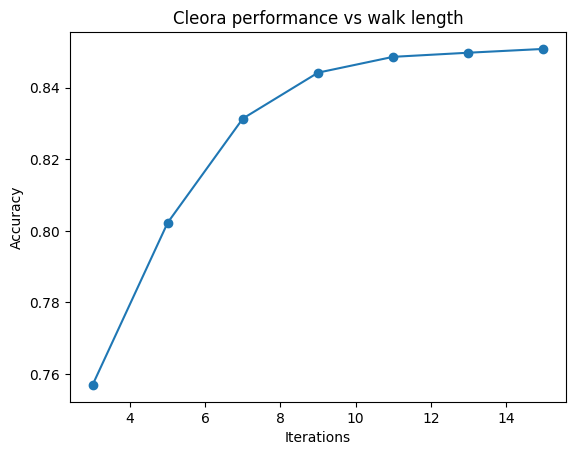

In [7]:
plt.plot(MARKOV_STEPS, result_df["Accuracy"], marker='o')
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Cleora performance vs walk length")
plt.show()

### Task 2

In [8]:
edges_task3 = []

with open(CONGRESS_EDGES_FILE) as f:
    for line in f:
        parts = line.strip().split(" ", 2)
        u, v = parts[0], parts[1]
        edges_task3.append(f"{u} {v}")

graph = SparseMatrix.from_iterator(
    iter(edges_task3),
    "complex::reflexive::product"
)

embeddings = embed(
    graph,
    feature_dim=30,
    num_iterations=5
)

X = embeddings

In [9]:
reducer = umap.UMAP(n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_scaled = StandardScaler().fit_transform(X)
X_tsne = tsne.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=SEED)
clusters = kmeans.fit_predict(X)

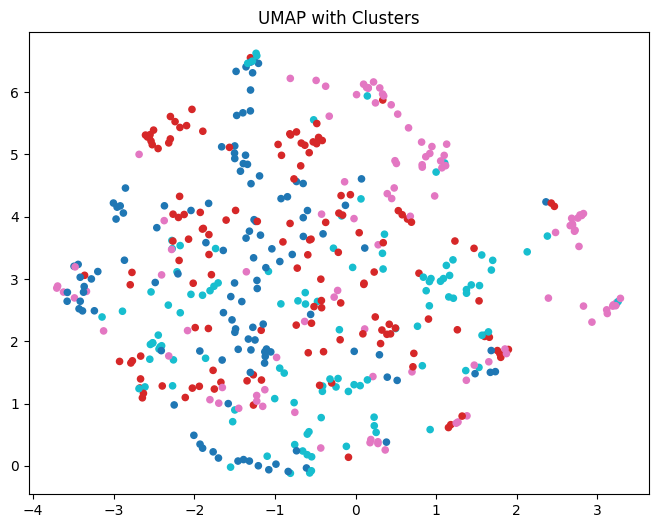

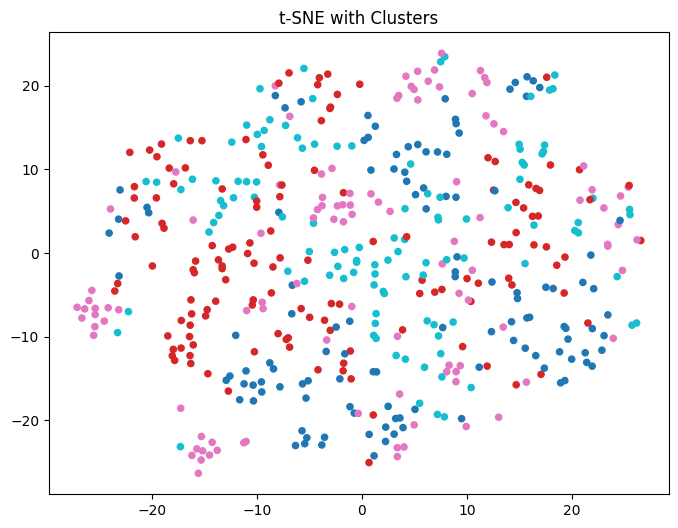

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters, cmap='tab10', s=20)
plt.title("UMAP with Clusters")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters, cmap='tab10', s=20)
plt.title("t-SNE with Clusters")
plt.show()

### Task 3

In [28]:
edges_task3 = pd.read_csv(GIT_EDGES_FILE)
targets_task3 = pd.read_csv(GIT_LABELS_FILE)

G_git_task3 = nx.from_pandas_edgelist(edges_task3, "id_1", "id_2")

largest_cc = max(nx.connected_components(G_git_task3), key=len)
G_git_task3 = G_git_task3.subgraph(largest_cc).copy()

G_git_task3 = nx.convert_node_labels_to_integers(G_git_task3)

labels_task3 = dict(zip(targets_task3["id"], targets_task3["ml_target"]))
labels_task3 = {int(k): v for k, v in labels_task3.items()}

mapping = {old: new for new, old in enumerate(largest_cc)}

labels_task3 = {
    mapping[node]: label
    for node, label in labels_task3.items()
    if node in mapping
}

nodes_subset = list(G_git_task3.nodes())[:SUBSET_SIZE]
G_git_task3 = G_git_task3.subgraph(nodes_subset).copy()

labels_task3 = {
    node: labels_task3[node]
    for node in G_git_task3.nodes()
    if node in labels_task3
}

print(f"Number of nodes: {G_git_task3.number_of_nodes()}")
print(f"Number of edges: {G_git_task3.number_of_edges()}")

Number of nodes: 5000
Number of edges: 61069


#### Node2Vec (Proximity)

In [29]:
model_n2v = Node2Vec(dimensions=128)
model_n2v.fit(G_git_task3)

emb_n2v = model_n2v.get_embedding()

#### GraRep (Proximity)

In [30]:
model_gr = GraRep(dimensions=128)
model_gr.fit(G_git_task3)

emb_gr = model_gr.get_embedding()

#### Role2Vec (Structural)

In [31]:
model_r2v = Role2Vec(dimensions=128)
model_r2v.fit(G_git_task3)

emb_r2v = model_r2v.get_embedding()

#### Evaluation

In [32]:
results = []

results.append(("Node2Vec", *evaluate_task3(G_git_task3, emb_n2v, labels_task3)))
results.append(("GraRep", *evaluate_task3(G_git_task3, emb_gr, labels_task3)))
results.append(("Role2Vec", *evaluate_task3(G_git_task3, emb_r2v, labels_task3)))

eval_results = pd.DataFrame(results, columns=["Method", "Accuracy", "F1"])

c:\Users\tymon\Desktop\Projects\Graph-Machine-Learning\.venv_lab2\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
print(eval_results.sort_values("Accuracy", ascending=False))

     Method  Accuracy        F1
0  Node2Vec  0.730667  0.426970
2  Role2Vec  0.728000  0.432953
1    GraRep  0.665333  0.509217
